In [1]:
import pandas as pd
import numpy as np
import os
pd.set_option('display.max_colwidth', 300)  # отключает обрезку строк

folder_path = "datasets"

dataset = pd.DataFrame({'text': {}, 'label' : {}})

window_context = 2

for file in os.listdir(folder_path):
    temp_dataset = pd.read_csv('datasets/'+file)

    if window_context > 0:
        texts = []
        new_labels = []
        for i in range(window_context, len(temp_dataset) - window_context):
            text = ''
                
            for j in range(i - window_context, i + window_context + 1):
                text += temp_dataset.iloc[j]['text'] + ' '

            texts.append(text.strip())
            new_labels.append(temp_dataset.iloc[i]['label'])

        dataset = pd.concat([dataset, pd.DataFrame({'text': texts, 'label': new_labels})], ignore_index=True)
    else:
        dataset = pd.concat([dataset, temp_dataset], ignore_index=True)

dataset.describe()

,label
count,51049.000000
mean,0.146937
std,0.354047
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [2]:
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task = "categorize_topic: "
model = SentenceTransformer("ai-forever/FRIDA").to(device)

def encode(texts):
    inputs = [task + t for t in texts]
    embeddings = model.encode(inputs, convert_to_tensor=True, normalize_embeddings=True)
    return embeddings.to("cpu")



tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")
llm_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-8B",
    torch_dtype=torch.float16,
    use_safetensors=True
    ).to(device)

def work_llm_model(prompt=str):
        messages = [
            {"role": "user", "content": prompt}
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )
        model_inputs = tokenizer([text], return_tensors="pt").to(device)

        generated_ids = llm_model.generate(
            **model_inputs,
            max_new_tokens=32768,
        )
        output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

        response = tokenizer.decode(output_ids, skip_special_tokens=True).strip("\n")
        return response

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
slice_dataset = dataset.sample(frac=0.7, random_state=42)
embeddings = encode(slice_dataset['text'])

# embeddings = encode(dataset['text'])

In [4]:
import hdbscan
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA

small_embeddings = PCA(n_components=200, random_state=42).fit_transform(embeddings)
clusterer = hdbscan.HDBSCAN(min_cluster_size=30,
                            min_samples=20,
                            cluster_selection_method='leaf', #leaf
                            metric='cosine', 
                            algorithm='generic')

labels = clusterer.fit_predict(small_embeddings)
labels += 1

slice_dataset['cluster_label'] = labels
slice_dataset['cluster_probability'] = clusterer.probabilities_

n_clusters = len(np.unique(labels))

colors = ["#D3D3D3",
    "#e6194b", "#3cb44b", "#ffe119", "#0082c8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#d2f53c", "#fabebe",
    "#008080", "#e6beff", "#aa6e28", "#fffac8", "#800000",
    "#aaffc3", "#808000", "#ffd8b1", "#000080", "#808080",
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5", 
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#1f78b4", "#33a02c", "#6a3d9a"   
]

cmap = mcolors.ListedColormap(colors[:n_clusters])

unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique.tolist(), counts.tolist()))

c:\Users\client\Viraly\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\client\Viraly\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


{0: 31972,
 1: 34,
 2: 34,
 3: 39,
 4: 244,
 5: 265,
 6: 45,
 7: 62,
 8: 31,
 9: 81,
 10: 42,
 11: 77,
 12: 156,
 13: 35,
 14: 40,
 15: 195,
 16: 57,
 17: 45,
 18: 124,
 19: 37,
 20: 98,
 21: 38,
 22: 108,
 23: 93,
 24: 125,
 25: 80,
 26: 724,
 27: 36,
 28: 90,
 29: 68,
 30: 163,
 31: 274,
 32: 69,
 33: 153}

In [5]:
cluster_names = {0: "Шум"}
for i in range(1, n_clusters):
    subset = slice_dataset[slice_dataset["cluster_label"] == i]
    sample_size = min(100, len(subset))
    texts = subset.sample(n=sample_size)['text'].to_list()
    prompt = f'''
        Ты — языковая модель, обученная выделять смысловые категории. Ниже приведён список из коротких текстов, принадлежащих одному тематическому кластеру. Проанализируй общий смысл этих текстов и сформулируй краткое, обобщающее название для этого кластера.

        Название должно быть:
        — очень кратким (1–2 слова),
        — точным по смыслу,
        — обобщающим суть всех или большинства текстов.

        Не добавляй вводных фраз (“Это кластер про…”), выдай только название.

        Пример (если тексты о футболе): Футбол
        Пример (если тексты о кино и сериалах): Развлечения

        Вот текста:
     ''' + '\n'.join(f'{j+1}. {t}' for j, t in enumerate(texts))
    name = work_llm_model(prompt)
    cluster_names[i] = name.strip()

cluster_names

{0: 'Шум',
 1: 'Цветы',
 2: 'Математика',
 3: 'Связь',
 4: 'Религия',
 5: 'Выживание в лесу',
 6: 'Путешествия',
 7: 'Автомобили',
 8: 'Сонные явления',
 9: 'Кулинария',
 10: 'Алкоголь',
 11: 'Пираты',
 12: 'Курение',
 13: 'Самопознание',
 14: 'Психология',
 15: 'Сексуальные темы',
 16: 'Сексуальные меньшинства',
 17: 'Фастфуд',
 18: 'Рак крови',
 19: 'Скульптура',
 20: 'Нацизм',
 21: 'Бессмертие',
 22: 'Афганистан',
 23: 'Терроризм',
 24: 'Империя Цукерберга',
 25: 'Роевой интеллект',
 26: 'Космос',
 27: 'НЛО',
 28: 'Конкурс',
 29: 'Силовые виды спорта',
 30: 'Экономика',
 31: 'Политика',
 32: 'Музыка',
 33: 'Кинематограф'}

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

reduced_3d_TSNE = TSNE(n_components=3, perplexity=30, learning_rate=200, init='pca', metric='cosine', random_state=42).fit_transform(small_embeddings)

reduced_2d_TSNE = TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca', metric='cosine', random_state=42).fit_transform(reduced_3d_TSNE)


legend_elements = []
for label in range(0, n_clusters):
    color = cmap(label)
    patch = mpatches.Patch(color=color, label=cluster_names[label])
    legend_elements.append(patch)

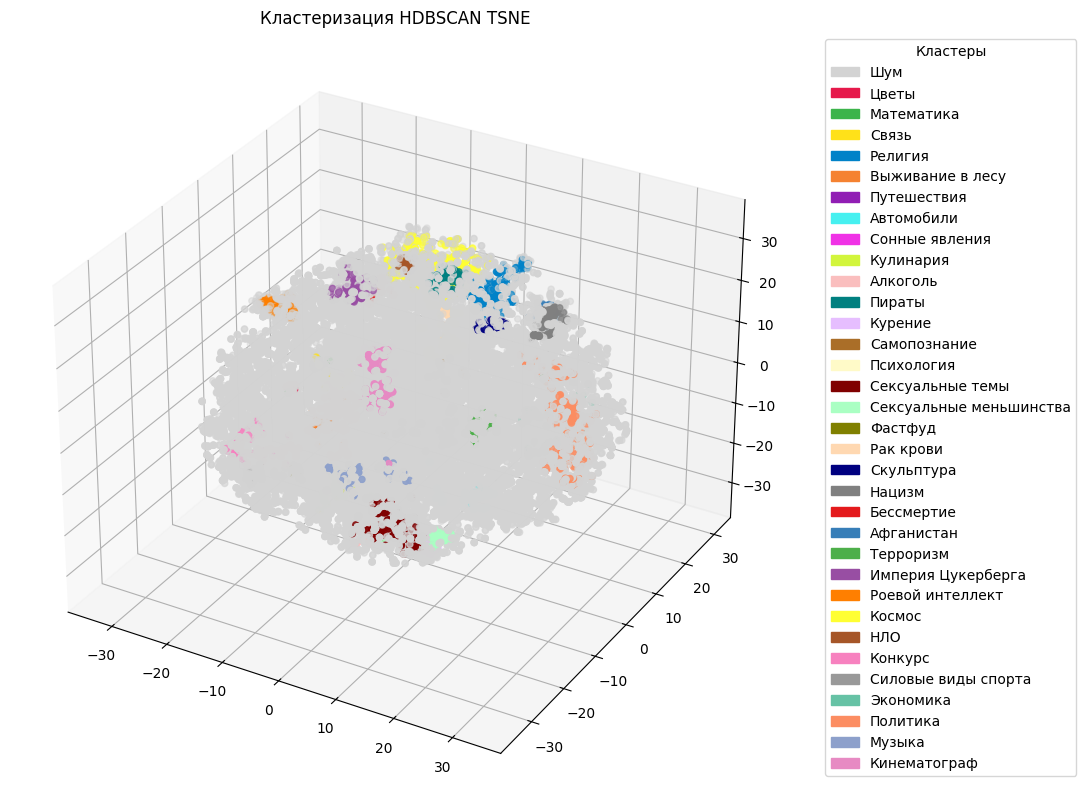

In [7]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(reduced_3d_TSNE[:, 0], reduced_3d_TSNE[:, 1], reduced_3d_TSNE[:, 2], c=slice_dataset['cluster_label'], cmap=cmap)
ax.legend(handles=legend_elements, title="Кластеры", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.title("Кластеризация HDBSCAN TSNE")
plt.savefig("3D_cluster_HDBSCAN_TSNE.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

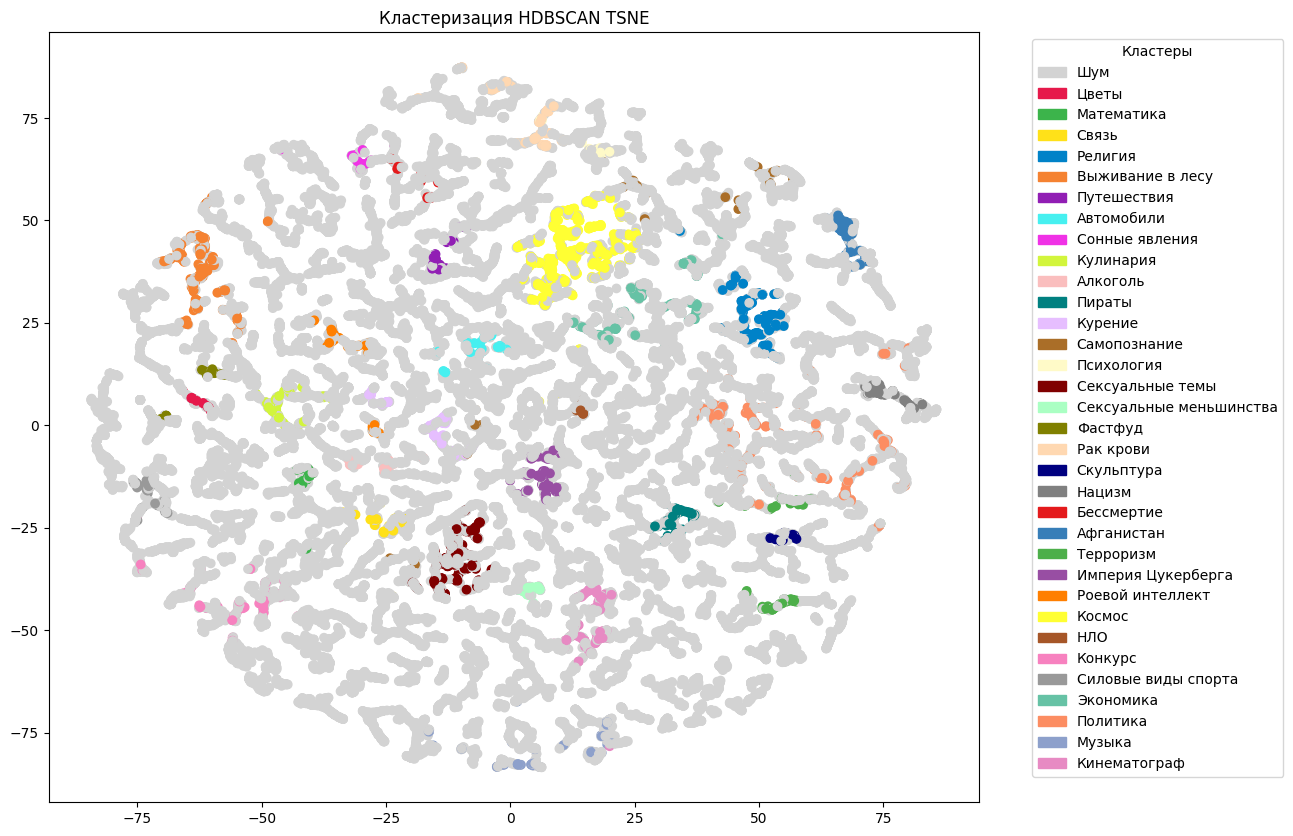

In [8]:
plt.figure(figsize=(12, 10))
plt.scatter(reduced_2d_TSNE[:,0], reduced_2d_TSNE[:,1], c=slice_dataset['cluster_label'], cmap=cmap)
plt.legend(handles=legend_elements, title="Кластеры", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.title("Кластеризация HDBSCAN TSNE")
plt.savefig("cluster_HDBSCAN_TSNE.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

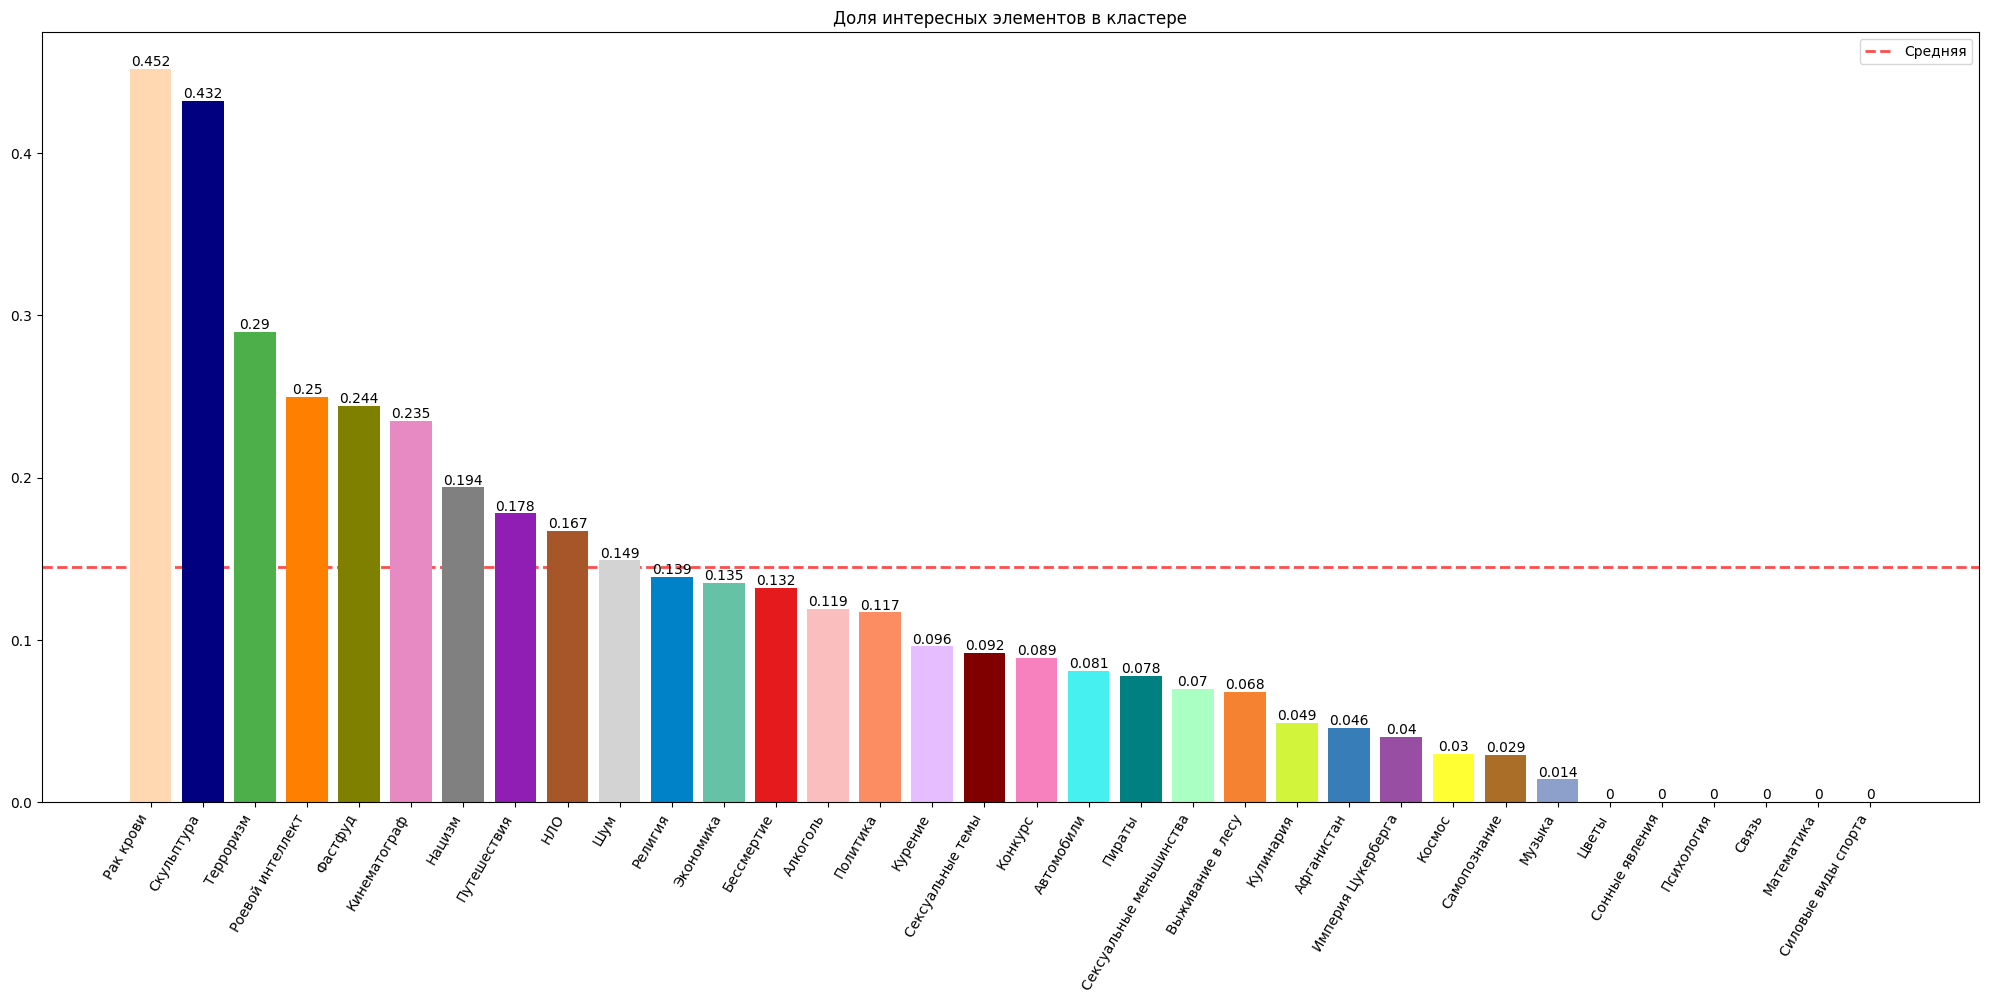

In [26]:
# Вычисляем средние значения по кластерам
bar_height = slice_dataset.groupby('cluster_label')['label'].mean().round(3)

# Сортируем по убыванию
bar_height_sorted = bar_height.sort_values(ascending=False)

# Получаем отсортированные метки и цвета
bar_labels = [list(cluster_names.values())[i] for i in bar_height_sorted.index]
bar_colors = [colors[:n_clusters][i] for i in bar_height_sorted.index]

fig, ax = plt.subplots(figsize=(25, 10))

# Добавляем пунктирную красную линию — среднюю по всем, на задний план
mean_value = slice_dataset['label'].mean()
ax.axhline(mean_value, color='red', linestyle='--', linewidth=2, label='Средняя', zorder=0, alpha=0.7)

# Отрисовка столбцов на переднем плане
bars = ax.bar(bar_labels, bar_height_sorted, color=bar_colors, zorder=2)
ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, rotation=60, ha='right', fontsize=10)
ax.bar_label(bars)

# Заголовок и легенда
plt.title("Доля интересных элементов в кластере")
ax.legend(loc='upper right')

# Сохранение и отображение
plt.savefig("interesting_clusters.png", dpi=500, bbox_inches='tight')
plt.show()
plt.close()

In [10]:
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(projection='3d')
# ax.scatter(reduced_3d_TSNE[:, 0], reduced_3d_TSNE[:, 1], reduced_3d_TSNE[:, 2], c=slice_dataset['label'], cmap='viridis')
# plt.title("Распределение по классам TSNE")
# plt.savefig("3D_distribution_TSNE.png", dpi=300, bbox_inches='tight')
# plt.show()
# plt.close()

In [11]:
# plt.figure(figsize=(12, 10))
# plt.scatter(reduced_2d_TSNE[:,0], reduced_2d_TSNE[:,1], c=slice_dataset['label'], cmap='viridis')
# plt.title("Распределение по классам TSNE")
# plt.savefig("distribution_TSNE.png", dpi=300, bbox_inches='tight')
# plt.show()
# plt.close()